
# Sentiment Analysis with NLP using TF-IDF and Logistic Regression

## Problem Definition

The objective of this project is to perform **Sentiment Analysis**
on customer reviews using Natural Language Processing (NLP).

The notebook demonstrates:
- Text preprocessing
- TF-IDF Vectorization
- Logistic Regression modeling
- Sentiment prediction
- Model evaluation

### Techniques Used
- Natural Language Processing (NLP)
- TF-IDF Vectorization
- Logistic Regression

### Evaluation Metrics
- Accuracy Score
- Precision
- Recall
- F1 Score
- Confusion Matrix

### Dataset Used
- Sample Customer Reviews Dataset


In [1]:

# Import Required Libraries

import pandas as pd
import numpy as np

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\patel\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [2]:

# Create Sample Customer Review Dataset

data = {
    'Review': [
        'The food was amazing and service was excellent',
        'Very bad experience and terrible customer service',
        'I loved the ambience and tasty food',
        'The restaurant was dirty and food was cold',
        'Fantastic experience highly recommended',
        'Worst restaurant I have ever visited',
        'Good quality food and friendly staff',
        'The food was average but service was slow',
        'Excellent taste and quick delivery',
        'Not satisfied with the food quality'
    ],

    'Sentiment': [
        'Positive',
        'Negative',
        'Positive',
        'Negative',
        'Positive',
        'Negative',
        'Positive',
        'Negative',
        'Positive',
        'Negative'
    ]
}

df = pd.DataFrame(data)

df.head()


,Review,Sentiment
0,The food was amazing and service was excellent,Positive
1,Very bad experience and terrible customer service,Negative
2,I loved the ambience and tasty food,Positive
3,The restaurant was dirty and food was cold,Negative
4,Fantastic experience highly recommended,Positive


In [3]:

# Dataset Information

print("Dataset Shape:", df.shape)

print("\nDataset Information:\n")
print(df.info())


Dataset Shape: (10, 2)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     10 non-null     object
 1   Sentiment  10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes
None


In [4]:

# Check Missing Values

print(df.isnull().sum())


Review       0
Sentiment    0
dtype: int64


In [5]:

# Text Preprocessing

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(f'[{string.punctuation}]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and apply stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

# Apply preprocessing
df['Processed_Review'] = df['Review'].apply(preprocess_text)

df.head()


,Review,Sentiment,Processed_Review
0,The food was amazing and service was excellent,Positive,food amaz servic excel
1,Very bad experience and terrible customer service,Negative,bad experi terribl custom servic
2,I loved the ambience and tasty food,Positive,love ambienc tasti food
3,The restaurant was dirty and food was cold,Negative,restaur dirti food cold
4,Fantastic experience highly recommended,Positive,fantast experi highli recommend


In [6]:

# Encode Sentiment Labels

df['Sentiment'] = df['Sentiment'].map({
    'Positive': 1,
    'Negative': 0
})

df.head()


,Review,Sentiment,Processed_Review
0,The food was amazing and service was excellent,1,food amaz servic excel
1,Very bad experience and terrible customer service,0,bad experi terribl custom servic
2,I loved the ambience and tasty food,1,love ambienc tasti food
3,The restaurant was dirty and food was cold,0,restaur dirti food cold
4,Fantastic experience highly recommended,1,fantast experi highli recommend


In [7]:

# TF-IDF Vectorization

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['Processed_Review'])

y = df['Sentiment']

print("TF-IDF Matrix Shape:", X.shape)


TF-IDF Matrix Shape: (10, 30)


In [8]:

# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (8, 30)
Testing Data Shape: (2, 30)


In [9]:

# Train Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully.")


Model Trained Successfully.


In [10]:

# Make Predictions

y_pred = model.predict(X_test)

print("Predictions:", y_pred)


Predictions: [1 1]


In [11]:

# Evaluate Model Performance

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy Score :", accuracy)
print("Precision Score:", precision)
print("Recall Score   :", recall)
print("F1 Score       :", f1)


Accuracy Score : 0.5
Precision Score: 0.5
Recall Score   : 1.0
F1 Score       : 0.6666666666666666


In [12]:

# Classification Report

report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



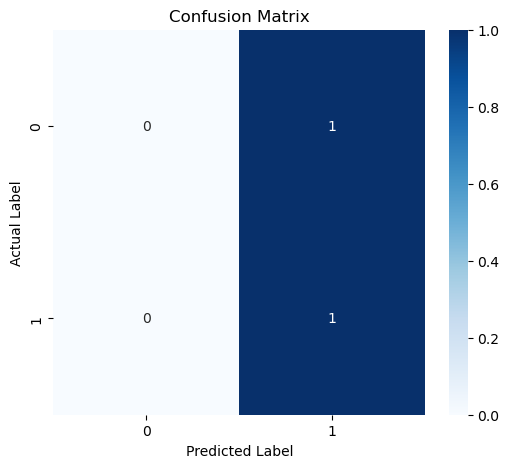

In [13]:

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


In [14]:

# Test Custom Review

sample_review = "The food was delicious and service was excellent"

processed_review = preprocess_text(sample_review)

vectorized_review = tfidf.transform([processed_review])

prediction = model.predict(vectorized_review)

if prediction[0] == 1:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")


Predicted Sentiment: Positive



# Sentiment Analysis and Insights

## Observations

- Positive reviews usually contain words like:
    - excellent
    - amazing
    - fantastic
    - delicious

- Negative reviews often contain words like:
    - terrible
    - worst
    - dirty
    - slow

## Advantages of TF-IDF

- Converts text into numerical features
- Gives importance to meaningful words
- Reduces impact of common words

## Advantages of Logistic Regression

- Simple and effective for text classification
- Fast training and prediction
- Works well with TF-IDF features

## Possible Improvements

- Use larger real-world datasets
- Apply advanced NLP techniques
- Use deep learning models like LSTM or BERT



# Conclusion

In this project:

- Customer reviews were preprocessed using NLP techniques.
- TF-IDF Vectorization converted text into numerical form.
- Logistic Regression was used for sentiment classification.
- Model performance was evaluated using:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
- Sentiment predictions were generated successfully.

Sentiment Analysis helps businesses understand customer opinions
and improve products and services.
